In [1]:
# Set up the file path, import packages, and define device
# Set up the file path
import sys
import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
sys.path.append(parent_dir)
print('Parent directory set to:', parent_dir)

# Specify the target directory
target_directory = '/local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_freq_3species_6rxns/'

# Import general packages
import torch
import numpy as np
from itertools import product, combinations_with_replacement
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.lines import Line2D

# Import CRN packages
from RL4CRN.iocrns.iocrn import IOCRN
from RL4CRN.utils.ic import IC

# Import Reward packages
from RL4CRN.rewards.deterministic import oscillation_error

# Import Visualization packages
from RL4CRN.utils.visualizations import plot_reactant_product_heatmap, plot_reactant_product_scatter, topology_graph
from RL4CRN.utils.visualizations import visualize_crn_diversity

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
N_CPUs = os.cpu_count() if os.cpu_count() is not None else 1
print(f'Number of CPUs available: {os.cpu_count()}') 

Parent directory set to: /local0/home/mfilo/git/CRN-GenerativeAI
Using device: cuda
Number of CPUs available: 128


In [2]:
# Flag to save generated figures
save_figures_flag = True

# Flag to resimulate the IOCRN dynamics of the halls of fame
resimulate_flag = False 

# Flag to load generated IOCRNs from trained models
generated_flag = True

# Flag for filtering out repeated IOCRN topologies
filter_flag = True
num_reactions_template = 4

# Parallel simulation flag
parallel_flag = True

# Set number of inputs and species labels
p = 1                                                   # Number of inputs
species_labels = ['X_1', 'X_2', 'X_3']                 # Species labels
mak_order = 2                                           # Maximum order of the mass-action reactions

# Time horizon for the simulation
t_f = 100                                               # Final time for the simulation
N_t = 1000                                              # Number of time steps in the simulation
time_horizon = np.linspace(0, t_f, N_t, dtype=np.float32)

# Construct the IOCRN inputs
periods = [10, 15, 20]
u_list = [np.array([1/p]) for p in periods]

# Construct the frequency list
f_list = u_list

# Construct the IOCRN initial conditions
ic = IC(names=species_labels, values=[[0.01, 0.01, 0.01]])

# Weight on the damping metric and initial time for peak detection
w = [0/10, 6/10, 1/10, 3/10]                              # [mean, frequency, damping, periodicity index]
t0 = 20.

# Construct the compute reward routine
def compute_reward(state):
    x0_list = ic.get_ic(state)
    return oscillation_error(state, u_list, x0_list, time_horizon, f_list=f_list, mean_list=None, w=w, t0=t0, LARGE_NUMBER=1e4)                                              

# Define path for the directories: hall of fame and models
base_path_hof = os.path.abspath(os.path.join(target_directory, 'hof'))
base_path_models = os.path.abspath(os.path.join(target_directory, 'models'))
print(f"Current working directory: {os.getcwd()}")
print(f"Base path for halls of fame: {base_path_hof}")
print(f"Base path for models: {base_path_models}")

Current working directory: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_freq_3species_6rxns/plots
Base path for halls of fame: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_freq_3species_6rxns/hof
Base path for models: /local0/home/mfilo/git/CRN-GenerativeAI/apps_results_MAK_REINFORCE/oscillators_freq_3species_6rxns/models


In [3]:
# Collect IOCRNs from halls of fame and those generated by trained models
# Get list of hall of fame files
hof_files = [f for f in os.listdir(base_path_hof) if f.startswith('hall_of_fame_') and f.endswith('.pth')]
print(f"Found {len(hof_files)} hall of fame files:")
for file in hof_files:
    print(f"- {file}")
print("-" * 40)

# Get list of generated files
generated_files = [f for f in os.listdir(base_path_models) if f.startswith('generated') and f.endswith('.pth')]
print(f"Found {len(generated_files)} generated files:")
for file in generated_files:
    print(f"- {file}")
print("-" * 40)

# Load the list of IOCRNs from each hall of fame file
hof_data = {}
for file in hof_files:
    file_path = os.path.join(base_path_hof, file)
    hof_data[file] = torch.load(file_path, weights_only=False)
    print(f"Loaded {file} with {len(hof_data[file])} entries.")

# Collect all IOCRNs from the halls of fame into a single list
hof_iocrns = []
for file, iocrn_list in hof_data.items():
    hof_iocrns.extend(iocrn_list)
print("-" * 40)
print(f"Total IOCRNs collected from all halls of fame: {len(hof_iocrns)}")
print("-" * 40)

if generated_flag:
    # Load the list of generated IOCRNs
    generated_data = {}
    for file in generated_files:
        file_path = os.path.join(base_path_models, file)
        generated_data[file] = torch.load(file_path, weights_only=False)
        print(f"Loaded {file} with {len(generated_data[file])} entries.")

    # Collect all IOCRNs from the generated files into a single list
    generated_iocrns = []
    for file, iocrn_list in generated_data.items():
        generated_iocrns.extend(iocrn_list)
    print("-" * 40)
    print(f"IOCRNs collected from all generated files: {len(generated_iocrns)}")

# Collect all IOCRNs into a single list
all_iocrns = hof_iocrns.copy()
if generated_flag:
    all_iocrns.extend(generated_iocrns)
print("-" * 40)
print(f"Total IOCRNs: {len(all_iocrns)}")

Found 10 hall of fame files:
- hall_of_fame_2025-12-28 10:32:40.pth
- hall_of_fame_2025-12-28 16:11:02.pth
- hall_of_fame_2025-12-28 22:45:35.pth
- hall_of_fame_2025-12-28 19:17:45.pth
- hall_of_fame_2025-12-29 15:45:37.pth
- hall_of_fame_2026-01-02 08:55:10.pth
- hall_of_fame_2025-12-27 11:08:37.pth
- hall_of_fame_2025-12-26 12:21:17.pth
- hall_of_fame_2025-12-27 19:37:00.pth
- hall_of_fame_2025-12-30 12:19:55.pth
----------------------------------------
Found 10 generated files:
- generated_2025-12-28 10:32:40.pth
- generated_2025-12-30 12:19:55.pth
- generated_2026-01-02 08:55:10.pth
- generated_2025-12-29 15:45:37.pth
- generated_2025-12-26 12:21:17.pth
- generated_2025-12-27 19:37:00.pth
- generated_2025-12-27 11:08:37.pth
- generated_2025-12-28 19:17:45.pth
- generated_2025-12-28 16:11:02.pth
- generated_2025-12-28 22:45:35.pth
----------------------------------------
Loaded hall_of_fame_2025-12-28 10:32:40.pth with 30 entries.
Loaded hall_of_fame_2025-12-28 16:11:02.pth with 30 

In [4]:
# Resimulate the dynamics of each IOCRN if the flag is set
if resimulate_flag:
    print("Resimulating IOCRN dynamics...")

    # Reset all IOCRNs
    for iocrn in all_iocrns:
        iocrn.reset()

    # Simulate each IOCRN
    if parallel_flag:
        results = Parallel(n_jobs=N_CPUs)(delayed(compute_reward)(iocrn) for iocrn in all_iocrns) 
    else:
        results = []
        for iocrn in all_iocrns:
            results.append(compute_reward(iocrn))

    # Unzip the results
    rewards_list, last_task_info_list = zip(*results)
    rewards_list = list(rewards_list)
    last_task_info_list = list(last_task_info_list)

    # Update the last task info in each IOCRN since running in parallel does not modify the IOCRNs themselves
    for i, iocrn in enumerate(all_iocrns):
        iocrn.last_task_info = last_task_info_list[i]            

Filtering topologically unique IOCRNs...
Number of topologically unique IOCRNs: 5742 out of 13100 total IOCRNs.


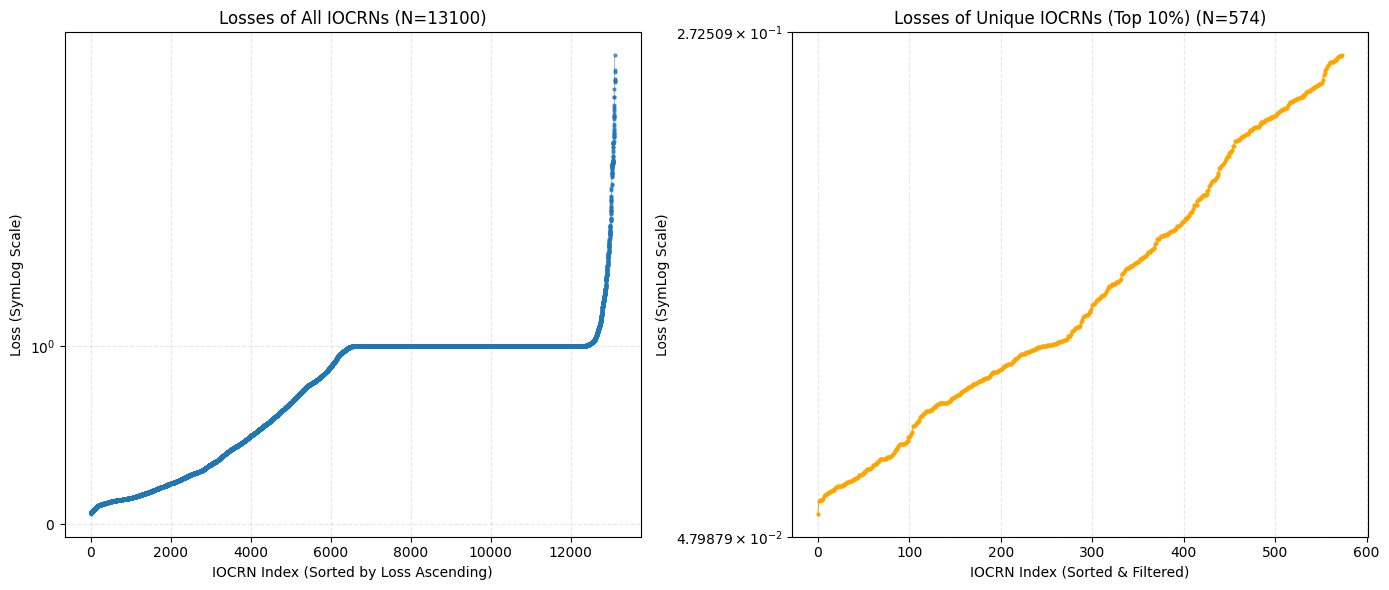

In [5]:
def plot_unique_rewards(all_iocrns, filter_flag=True, top_percentile=100, figsize=(14, 6)):
    """
    Sorts IOCRNs by reward (loss), optionally filters for topological uniqueness, 
    and plots the reward distribution.

    Args:
        all_iocrns (list): List of IOCRN objects. Each must have .last_task_info['reward'] 
                           and .is_topologically_equal().
        filter_flag (bool): If True, removes topologically duplicate CRNs, keeping the 
                            best-performing version of each topology.
        top_percentile (float): If < 100, restricts the "Unique" plot to the top X% 
                                of topologies. (e.g., 10 = top 10%).
        figsize (tuple): Figure size for the plot.
    """
    
    # 1. Sort all IOCRNs by reward/loss.
    # User Request: "Plotting a loss" -> "Lower values on the left".
    # This implies Ascending Order (Smallest/Best -> Largest/Worst).
    all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)

    # 2. Filter topologically unique IOCRNs
    if filter_flag:
        print("Filtering topologically unique IOCRNs...")
        all_iocrns_sorted_filtered = []
        
        if all_iocrns_sorted:
            # The list is sorted [Best, ..., Worst].
            # To keep the BEST version of each topology, we iterate FORWARD.
            # The first time we see a topology, it is the best one (lowest index in sorted list).
            unique_indices = []
            seen_topologies = []
            
            for i in range(len(all_iocrns_sorted)):
                candidate = all_iocrns_sorted[i]
                is_new = True
                for seen in seen_topologies:
                    if candidate.is_topologically_equal(seen):
                        is_new = False
                        break
                
                if is_new:
                    seen_topologies.append(candidate)
                    unique_indices.append(i)
            
            all_iocrns_sorted_filtered = [all_iocrns_sorted[i] for i in unique_indices]
            
        print(f"Number of topologically unique IOCRNs: {len(all_iocrns_sorted_filtered)} out of {len(all_iocrns_sorted)} total IOCRNs.")

    else:
        all_iocrns_sorted_filtered = all_iocrns_sorted

    # 3. Apply Percentile Cutoff (to the Filtered list)
    if top_percentile < 100:
        n_total = len(all_iocrns_sorted_filtered)
        n_keep = max(1, int(n_total * (top_percentile / 100.0)))
        
        # Keep the FIRST n_keep items (Lowest Loss / Best Performance)
        all_iocrns_sorted_filtered = all_iocrns_sorted_filtered[:n_keep]
        title_suffix = f" (Top {top_percentile}%)"
    else:
        title_suffix = ""

    # 4. Extract Rewards
    rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]
    rewards_sorted_filtered = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted_filtered]

    # 5. Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

    # Left Plot: All IOCRNs
    ax1.plot(rewards_sorted, marker='o', markersize=2, linestyle='-', linewidth=0.5, alpha=0.7)
    ax1.set_yscale('symlog') # symlog handles negative rewards better than log
    ax1.set_xlabel('IOCRN Index (Sorted by Loss Ascending)')
    ax1.set_ylabel('Loss (SymLog Scale)')
    ax1.set_title(f'Losses of All IOCRNs (N={len(rewards_sorted)})')
    ax1.grid(True, which="both", ls="--", alpha=0.3)

    # Right Plot: Unique / Top Percentile
    ax2.plot(rewards_sorted_filtered, marker='o', color='orange', markersize=2, linestyle='-', linewidth=0.8)
    ax2.set_yscale('symlog') # Kept as symlog
    ax2.set_xlabel('IOCRN Index (Sorted & Filtered)')
    ax2.set_ylabel('Loss (SymLog Scale)')
    ax2.set_title(f'Losses of Unique IOCRNs{title_suffix} (N={len(rewards_sorted_filtered)})')
    ax2.grid(True, which="both", ls="--", alpha=0.3)
    
    # Ensure tick labels are visible on Y axis
    ax2.yaxis.set_minor_formatter(plt.ScalarFormatter())

    plt.tight_layout()
    plt.show()

    return all_iocrns_sorted, all_iocrns_sorted_filtered

# Plot the rewards with filtering and top percentile options
all_iocrns_sorted, all_iocrns_sorted_filtered = plot_unique_rewards(all_iocrns, filter_flag=filter_flag, top_percentile=10, figsize=(14, 6))

Reward for IOCRN index 0: 0.058193467810233074


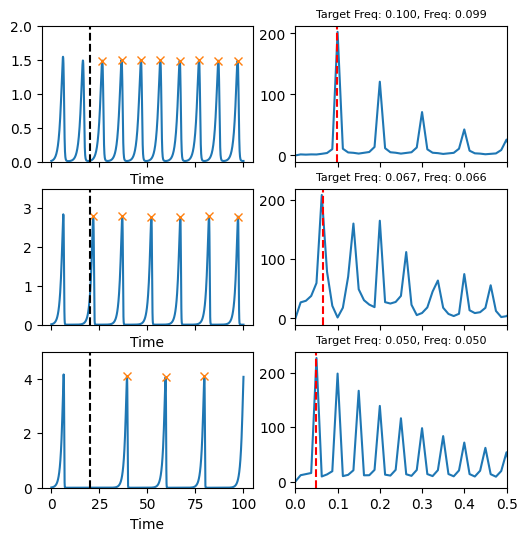

In [7]:
from scipy.signal import find_peaks
# Index of IOCRN
i = 0

# Extract the simulation info
info = all_iocrns_sorted_filtered[i].last_task_info
t = info["time_horizon"]
outs = info["outputs"]
reward = info["reward"]
print(f"Reward for IOCRN index {i}: {reward}")

# Focus only on t >= t0
mask = t >= t0

# Get the sampling time and number of samples
dt = float(np.mean(np.diff(t[mask])))
N = int(mask.sum())

# Construct the frequency axis
freqs = np.fft.rfftfreq(N, d=dt)

ylim = [2, 3.5, 5]
fig, axes = plt.subplots(nrows=len(f_list), ncols=2, figsize=(6, 2*len(f_list)), sharex='col')
for j in range(len(f_list)):

    # Mask out the signal
    y = outs[j][0, mask]

    # Remove the mean
    y_mean = np.mean(y)
    y = y - y_mean

    # Compute the FFT and its magnitude
    Y = np.fft.rfft(y)
    mag = np.abs(Y)

    # Compute peaks in time domain
    dyn = float(np.max(y) - np.min(y)) 
    prom = max(0.01, 0.05 * dyn)
    peaks_idx = find_peaks(y, prominence=prom)[0]
    peaks_time = t[mask][peaks_idx]
    peaks = y[peaks_idx] + y_mean

    # Estimate Frequency from peaks
    periods = np.diff(peaks_time)
    avg_period = np.mean(periods)
    estimated_frequency = 1.0 / avg_period

    # Plot the frequency contents and time response
    axes[j, 0].plot(t, outs[j][0, :])
    axes[j, 0].plot(peaks_time, peaks, "x")
    axes[j, 0].axvline(x=t0, color="black", ls="--")
    axes[j, 0].set_ylim(0, ylim[j])
    axes[j, 0].set_xlabel('Time')
    axes[j, 1].plot(freqs, mag)
    axes[j, 1].axvline(x=estimated_frequency, color="red", ls="--")
    axes[j, 1].set_xlim(0, 0.5)
    axes[j, 1].set_title(f'Target Freq: {f_list[j][0]:.3f}, Freq: {estimated_frequency:.3f}', fontsize=8)

In [ ]:
# Select the top IOCRNs and top topologically unique IOCRNs to visualize
n_unfiltered = 100
n_filtered = 10

In [ ]:
# Plot the responses of the top IOCRNs (topologically not unique)
ax = None
print("sorting...")
all_iocrns_sorted = sorted(all_iocrns, key=lambda iocrn: iocrn.last_task_info['reward'], reverse=False)
print("done ... ")
for i in range(n_unfiltered):
    x0_list = ic.get_ic(all_iocrns_sorted[i])
    fig, ax = all_iocrns_sorted[i].plot_transient_response(axes=ax, alpha=0.1)
ax[0].set_title(ax[0].get_title() + ' - Unfiltered')
print(f'Unfiltered: IOCRN # {0} has a reward of {all_iocrns_sorted[0].last_task_info["reward"]}')
print(f'Unfiltered: IOCRN # {n_unfiltered} has a reward of {all_iocrns_sorted[n_unfiltered-1].last_task_info["reward"]}')

# Plot the responses of the top topologically unique IOCRNs
ax = None
for i in range(n_filtered):
    x0_list = ic.get_ic(all_iocrns_sorted_filtered[i])
    fig, ax = all_iocrns_sorted_filtered[i].plot_transient_response(axes=ax)
ax[0].set_title(ax[0].get_title() + ' - Topologically Unique')
print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')
print(f'Filtered: IOCRN # {n_filtered} has a reward of {all_iocrns_sorted_filtered[n_filtered-1].last_task_info["reward"]}')

In [ ]:
# Plot the reactant-product scatter for the top unfiltered IOCRNs
rewards_sorted = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted]
rewards_sorted_filtered = [iocrn.last_task_info['reward'] for iocrn in all_iocrns_sorted_filtered]

plot_reactant_product_scatter(
    all_iocrns_sorted_filtered[0:n_filtered],
    perf=rewards_sorted_filtered[0:n_filtered],
    species_labels=species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="viridis",
    max_ticks=30,
    figsize=(6, 5),
    jitter_scale=0.45,
    use_plotly=True  # ENABLE INTERACTIVE PLOTTING WITH PLOTLY
)

# Plot the reactant-product heatmap for the top filtered IOCRNs (topologically unique)
plot_reactant_product_heatmap(
    all_iocrns_sorted_filtered[0:n_filtered],
    species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="YlGnBu",
    max_ticks=30,
    figsize=(7, 6),
)

In [ ]:
# Visualize the diversity of the top filtered IOCRNs (topologically unique)
visualize_crn_diversity(all_iocrns_sorted_filtered[:n_filtered], perf=rewards_sorted_filtered[:n_filtered], k=None, t=12, layout_method="mds", label_percentile=50, alpha=10.0, unique=True)  # <--- ENABLE REWARD-WEIGHTED TOPOLOGY WITH ALPHA=10.0

In [ ]:
# Select three IOCRNs to highlight their responses
iocrn_indices_to_highlight = [0, 1]

# Print the highlighted IOCRNs and their rewards
for idx in iocrn_indices_to_highlight:
    iocrn = all_iocrns_sorted_filtered[idx]
    reward = iocrn.last_task_info['reward']
    print(f'IOCRN {idx} (Loss: {reward}):')
    print(iocrn)
    print('-'*40)

In [ ]:
# Plot the responses (all species) of the following selected IOCRNs
fig, ax = plt.subplots(len(species_labels), len(iocrn_indices_to_highlight), figsize=(8, 2*len(species_labels)), sharex=True)

for i in range(len(iocrn_indices_to_highlight)):
    info = all_iocrns_sorted_filtered[iocrn_indices_to_highlight[i]].last_task_info
    t = info["time_horizon"]
    trajectories = info["trajectories"]
    ax[0, i].set_title(f'IOCRN #{iocrn_indices_to_highlight[i]} (Loss: {info["reward"]})', fontsize=6)
    for j in range(len(species_labels)):
        if i == 0:
            ax[j, i].set_ylabel(species_labels[j])
        for k in range(len(trajectories)):
            try:
                ax[j, i].plot(t, trajectories[k][j, :], alpha=0.7, linewidth=0.1)
            except Exception:
                continue

In [ ]:
# Transient dynamics plot
Normalize = True
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

fig, ax = plt.subplots(figsize=(2.5, 1.85), constrained_layout=True) 

# --------- Plot all traces in light gray (topologically unique) ----------
alpha_bg = 0.1     # transparency for background traces
lw_bg = 0.8         # line width for background traces
time_shift = 0      # shift time 

for i in range(n_filtered):
    info = all_iocrns_sorted_filtered[i].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]
    mask = t >= t0

    for j in range(len(outs)):
        peak = np.max(outs[j][0, mask])
        if Normalize:
            outs[j][0, :] = outs[j][0, :] / peak
        ax.plot(t, outs[j][0, :],
                color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)

print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')
print(f'Filtered: IOCRN # {n_filtered-1} has a reward of {all_iocrns_sorted_filtered[n_filtered-1].last_task_info["reward"]}')

# --------- Highlight the selected IOCRNs ----------
lw_hi = 1

for i in range(len(iocrn_indices_to_highlight)):
    info = all_iocrns_sorted_filtered[iocrn_indices_to_highlight[i]].last_task_info
    t = info["time_horizon"] + time_shift
    outs = info["outputs"]
    mask = t >= t0

    color = f"C{i}"  # Matplotlib standard cycle
    label = f"I/O CRN {i+1}"

    for j in range(len(outs)):
        peak = np.max(outs[j][0, mask])
        if Normalize:
            outs[j][0, :] = outs[j][0, :] / peak
        ax.plot(
            t, outs[j][0, :],
            color=color, linewidth=lw_hi,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )

# --------- Axes cosmetics ----------
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --------- Scales/limits (set before setpoint lines so we know xmin/xmax) ----------
ax.set_xscale("linear")
if Normalize:
    ax.set_yscale("linear")
    ax.set_ylim(0, 1.1)
# ax.set_ylim(0, 5)
# ax.set_xlim(time_shift, 100 + time_shift)


# 2) Legend for colored lines should not have alpha:
#    use proxy artists with alpha=1 so legend is fully opaque.
color_handles = [Line2D([0], [0], color=f"C{i}", lw=lw_hi, alpha=1.0) for i in range(len(iocrn_indices_to_highlight))]
color_labels  = [f"I/O CRN {i}" for i in iocrn_indices_to_highlight]

# Dashed Line for Setpoint
setpoint_handle = Line2D([0], [0], color="0.2", lw=0.9, ls="--")
handles = color_handles #  + [setpoint_handle]
labels  = color_labels #+ ["Setpoint"]

# ax.set_xticks(np.array([0, 10, 100]) + time_shift)
# ax.set_xticklabels(ax.get_xticks() - time_shift, rotation=0)

ax.legend(handles=handles, labels=labels, frameon=True, loc="upper right", handlelength=2)
plt.show()

if save_figures_flag is True:
    fig.savefig(os.path.join(target_directory, 'plots', "oscillators_freq_3species_6rxns_transient_dynamics.pdf"))

In [ ]:
# Frequency contents plot
Normalize = True
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

fig, ax = plt.subplots(figsize=(2.5, 1.85), constrained_layout=True) 

# --------- Plot all traces in light gray (topologically unique) ----------
alpha_bg = 0.3     # transparency for background traces
lw_bg = 0.8         # line width for background traces

for i in range(n_filtered):
    info = all_iocrns_sorted_filtered[i].last_task_info
    t = info["time_horizon"]
    outs = info["outputs"]
    mask = t >= t0
    dt = float(np.mean(np.diff(t[mask])))
    N = int(mask.sum())
    freqs = np.fft.rfftfreq(N, d=dt)

    for j in range(len(outs)):
        y = outs[j][0, mask]
        y = y - np.mean(y)
        Y = np.fft.rfft(y)
        mag = np.abs(Y)
        if Normalize:
            mag = mag / (np.max(mag) + 1e-12)
        ax.plot(freqs, mag, 
                color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)

print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')
print(f'Filtered: IOCRN # {n_filtered-1} has a reward of {all_iocrns_sorted_filtered[n_filtered-1].last_task_info["reward"]}')

# --------- Highlight the selected IOCRNs ----------
lw_hi = 1

for i in range(len(iocrn_indices_to_highlight)):
    info = all_iocrns_sorted_filtered[iocrn_indices_to_highlight[i]].last_task_info
    t = info["time_horizon"]
    outs = info["outputs"]

    color = f"C{i}"  # Matplotlib standard cycle
    label = f"I/O CRN {i+1}"

    for j in range(len(outs)):
        y = outs[j][0, mask]
        y = y - np.mean(y)
        Y = np.fft.rfft(y)
        mag = np.abs(Y)
        if Normalize:
            mag = mag / (np.max(mag) + 1e-12)
        ax.plot(
            freqs, mag, 
            color=color, linewidth=lw_hi,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )

# --------- Axes cosmetics ----------
ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# --------- Scales/limits (set before setpoint lines so we know xmin/xmax) ----------
ax.set_xscale("linear")
# ax.set_ylim(0, 1.01)
ax.set_xlim(0, 0.15)
# ax.set_xlim(time_shift, t_f + time_shift)

# Desired frequencies
for desired_freq in f_list:
    ax.axvline(x=desired_freq, color="0.2", lw=0.9, ls="--", zorder=2)

# 2) Legend for colored lines should not have alpha:
#    use proxy artists with alpha=1 so legend is fully opaque.
color_handles = [Line2D([0], [0], color=f"C{i}", lw=lw_hi, alpha=1.0) for i in range(len(iocrn_indices_to_highlight))]
color_labels  = [f"I/O CRN {i}" for i in iocrn_indices_to_highlight]

ax.legend(handles=handles, labels=labels, frameon=True, loc="upper right", handlelength=2)
plt.show()

if save_figures_flag is True:
    fig.savefig(os.path.join(target_directory, 'plots', "oscillators_freq_3species_6rxns_fourier.pdf"))

In [ ]:
# Frequency contents plots
Normalize = True
plt.rcParams.update({
    "font.size": 6,
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "legend.fontsize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.2,
    "figure.dpi": 120,
    "savefig.dpi": 600,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.02,
})

fig, axes = plt.subplots(nrows=len(f_list), ncols=1, figsize=(2.5, 1.85), constrained_layout=True, sharex=True) 

# --------- Plot all traces in light gray (topologically unique) ----------
alpha_bg = 0.3     # transparency for background traces
lw_bg = 0.8         # line width for background traces

for i in range(n_filtered):
    info = all_iocrns_sorted_filtered[i].last_task_info
    t = info["time_horizon"]
    outs = info["outputs"]
    mask = t >= t0
    dt = float(np.mean(np.diff(t[mask])))
    N = int(mask.sum())
    freqs = np.fft.rfftfreq(N, d=dt)

    for j in range(len(outs)):
        y = outs[j][0, mask]
        y = y - np.mean(y)
        Y = np.fft.rfft(y)
        mag = np.abs(Y)
        if Normalize:
            mag = mag / (np.max(mag) + 1e-12)
        axes[j].plot(freqs, mag, 
                color="0.6", alpha=alpha_bg, linewidth=lw_bg, zorder=1)

print(f'Filtered: IOCRN # {0} has a reward of {all_iocrns_sorted_filtered[0].last_task_info["reward"]}')
print(f'Filtered: IOCRN # {n_filtered-1} has a reward of {all_iocrns_sorted_filtered[n_filtered-1].last_task_info["reward"]}')

# --------- Highlight the selected IOCRNs ----------
lw_hi = 1

for i in range(len(iocrn_indices_to_highlight)):
    info = all_iocrns_sorted_filtered[iocrn_indices_to_highlight[i]].last_task_info
    t = info["time_horizon"]
    outs = info["outputs"]

    color = f"C{i}"  # Matplotlib standard cycle
    label = f"I/O CRN {i+1}"

    for j in range(len(outs)):
        y = outs[j][0, mask]
        y = y - np.mean(y)
        Y = np.fft.rfft(y)
        mag = np.abs(Y)
        if Normalize:
            mag = mag / (np.max(mag) + 1e-12)
        axes[j].plot(
            freqs, mag, 
            color=color, linewidth=lw_hi,
            zorder=3,
            label=label if j == 0 else None   # label once per i
        )

# --------- Axes cosmetics ----------
for ax in axes:
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))

    ax.grid(True, which="major", linewidth=0.6, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # --------- Scales/limits (set before setpoint lines so we know xmin/xmax) ----------
    ax.set_xscale("linear")
    # ax.set_ylim(0, 1.01)
    ax.set_xlim(0, 0.15)
    # ax.set_xlim(time_shift, t_f + time_shift)

# Desired frequencies
for j in range(len(f_list)):
    desired_freq = f_list[j]
    axes[j].axvline(x=desired_freq, color="0.2", lw=0.9, ls="--", zorder=2)

# 2) Legend for colored lines should not have alpha:
#    use proxy artists with alpha=1 so legend is fully opaque.
color_handles = [Line2D([0], [0], color=f"C{i}", lw=lw_hi, alpha=1.0) for i in range(len(iocrn_indices_to_highlight))]
color_labels  = [f"I/O CRN {i}" for i in iocrn_indices_to_highlight]

# ax.legend(handles=handles, labels=labels, frameon=True, loc="upper right", handlelength=2)
plt.show()

# if save_figures_flag is True:
    # fig.savefig(os.path.join(target_directory, 'plots', "oscillators_freq_3species_6rxns_fourier.pdf"))

In [ ]:
# Reactant-Product Scatter Plot
plot_dic = {
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 6,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.2,
        "lines.linewidth": 1.2,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }

fig = plot_reactant_product_scatter(
    all_iocrns_sorted_filtered[0:n_filtered],
    perf=rewards_sorted_filtered[0:n_filtered],
    species_labels=species_labels,
    max_order= mak_order,
    num_reactions_template=num_reactions_template,
    title="",
    cmap_name="viridis",
    max_ticks=30,
    figsize=(2*1.75, 1.65*1.75),
    jitter_scale=0.45,
    use_plotly=False,
    plot_dic=plot_dic,
    marker_size=4
)

if save_figures_flag is True:
    fig.savefig(os.path.join(target_directory, 'plots', "oscillators_freq_3species_6rxns_reactant_product_scatter.pdf"))

In [ ]:
# Topological diversity graph
plot_dic = {
        "font.size": 6,
        "axes.labelsize": 6,
        "axes.titlesize": 6,
        "legend.fontsize": 6,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.2,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.02,
    }

graph_dic = {
        "fontsize": 3,                  # font size for node labels 
        "edgewidth": 0.1,               # width of the edges in the graph
        "nodesize_multiplier":10,       # multiplier for node sizes
        "nodesize_offset": 0,           # offset for node sizes
        "show_colorbar": False,         # whether to show colorbar for node colors
        "innersize_ratio": 3,           # ratio for inner size of nodes
        "inner_node_linewidth": 0.1,    # width of the inner node borders 
        "outer_node_linewidth": 3.0     # width of the outer node borders
    }

fig = visualize_crn_diversity(
    all_iocrns_sorted_filtered[:n_filtered], 
    perf=rewards_sorted_filtered[:n_filtered], 
    k=None, 
    t=12, 
    layout_method="mds", 
    label_percentile=50, 
    alpha=10.0, 
    unique=True, 
    plot_dic=plot_dic,
    graph_dic=graph_dic,
    figsize=(2, 2)
)

if save_figures_flag is True:
    fig.savefig(os.path.join(target_directory, 'plots', "oscillators_freq_3species_6rxns_topological_diversity.pdf"))